<a href="https://colab.research.google.com/github/Reconocimiento-de-patrones-UNQ/svm/blob/main/Clase5_Reconocimiento_de_Patrones2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clase 5 — Support Vector Machines y métodos de kernel

**Maestría en Bioinformática y Biología de Sistemas — UNQ**
**Reconocimiento de Patrones en Bioinformática**

---

## Objetivos de esta clase

Hasta acá vimos modelos **lineales** (regresión logística regularizada). Hoy generalizamos a modelos **no lineales** vía el truco del kernel.

Al final de la hora vas a poder:

1. Entender el concepto de **margen máximo** y **vectores de soporte**.
2. Manejar el parámetro $C$ (control de soft margin).
3. Aplicar el **truco del kernel**: lineal, polinómico, RBF.
4. Elegir y tunear el parámetro **γ (gamma)** del kernel RBF.
5. Conocer **kernels específicos para datos biológicos** (string kernels para secuencias).

## Cómo está organizada la clase

- **Bloque 1:** Margen máximo y vectores de soporte. Datasets de hoy.
- **Bloque 2:** SVM lineal y el parámetro C. **Ejercicio 1.**
- **Bloque 3:** El truco del kernel. RBF. **Ejercicio 2.**
- **Bloque 4:** Tuning de C y γ. **Ejercicio 3.**
- **Bloque 5:** Kernels biológicos. **Ejercicio 4.**
- **Cierre:** **Ejercicio 5** integrador.

In [ ]:
# !pip install numpy pandas matplotlib seaborn scikit-learn scipy statsmodels --quiet

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("Setup listo.")

Setup listo.


---

# Intuición geométrica

## El problema de la separación lineal

Imaginá dos clases en el plano. Hay **infinitos hiperplanos** que las separan. ¿Cuál elegir?

**SVM elige el hiperplano de margen máximo:** el que está más alejado de los puntos más cercanos de cada clase.

## Conceptos clave

- **Margen**: distancia entre el hiperplano y los puntos más cercanos.
- **Vectores de soporte**: los puntos que están en la frontera del margen (definen el hiperplano).
- **Soft margin (C)**: permite cierta violación del margen a cambio de mejor generalización.

### Cómo elegir C: el trade-off
Recordá: *C* regula cuánto castigamos las violaciones del margen.

**C grande (ej: C = 100):**

 - El modelo paga un costo alto por cada punto que viola el margen.
 - Para evitar pagar ese costo, el optimizador prefiere márgenes angostos que dejen pocos puntos adentro.
 - El hiperplano se ajusta muy de cerca a los datos de entrenamiento.

**Resultado:** modelo más complejo, más riesgo de sobreajuste. La regularización es débil.

**C chico (ej: C = 0.01):**

 - El modelo casi no castiga las violaciones.
 - El optimizador puede permitirse márgenes amplios aunque eso deje muchos puntos del lado "incorrecto".
 - El hiperplano queda "suave" y menos sensible a puntos específicos del training.

**Resultado:** modelo más simple, más regularizado. Generaliza mejor si la regularización es la adecuada, pero corre riesgo de sub-ajuste si exageramos.

Resumen intuitivo:

|C grande | C chico|
| :--- | :--- |
| "No quiero ningún error en train" | "Acepto algunos errores en train si así soy más estable" |
| Pocos vectores de soporte | Muchos vectores de soporte |
| Margen angosto | Margen amplio |
| Baja regularización (modelo complejo) | Alta regularización (modelo simple) |
| Riesgo: sobreajuste | Riesgo: sub-ajuste |

Donde está el "C óptimo" es una propiedad del dataset y se busca por cross-validation. No hay un valor universalmente bueno.


## Datasets de hoy

Hoy usamos:

1. Un dataset 2D sintético para **visualizar** todo.
2. Breast cancer Wisconsin (Clase 4) para aplicación real.
3. Un dataset sintético tipo **secuencias** para introducir string kernels.

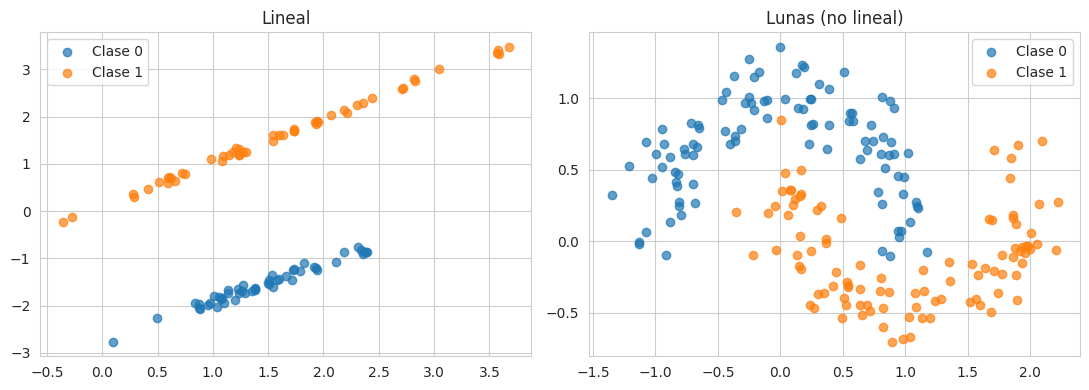

In [ ]:
from sklearn.datasets import make_classification, make_moons

# 1) Dataset 2D linealmente separable (casi)
X_lin, y_lin = make_classification(
    n_samples=100, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=1.5, random_state=42
)

# 2) Dataset 2D NO linealmente separable (lunas)
X_moons, y_moons = make_moons(n_samples=200, noise=0.15, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, X_, y_, title in [(axes[0], X_lin, y_lin, "Lineal"),
                           (axes[1], X_moons, y_moons, "Lunas (no lineal)")]:
    for k in [0, 1]:
        ax.scatter(X_[y_ == k, 0], X_[y_ == k, 1], label=f"Clase {k}", alpha=0.7)
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

---

# SVM lineal y el parámetro C

## El problema de optimización

$$\min_{w, b, \xi} \frac{1}{2}\|w\|^2 + C \sum_i \xi_i$$

sujeto a $y_i (w^T x_i + b) \geq 1 - \xi_i$ y $\xi_i \geq 0$.

- $\xi_i$: variables de holgura (cuánto se "permite" violar el margen).
- $C$: balance entre margen grande (regularización) y pocas violaciones.

**Conexión con Ridge:** el término $\|w\|^2$ es exactamente la penalización L2. SVM lineal es esencialmente regresión logística con pérdida hinge en lugar de log-likelihood.

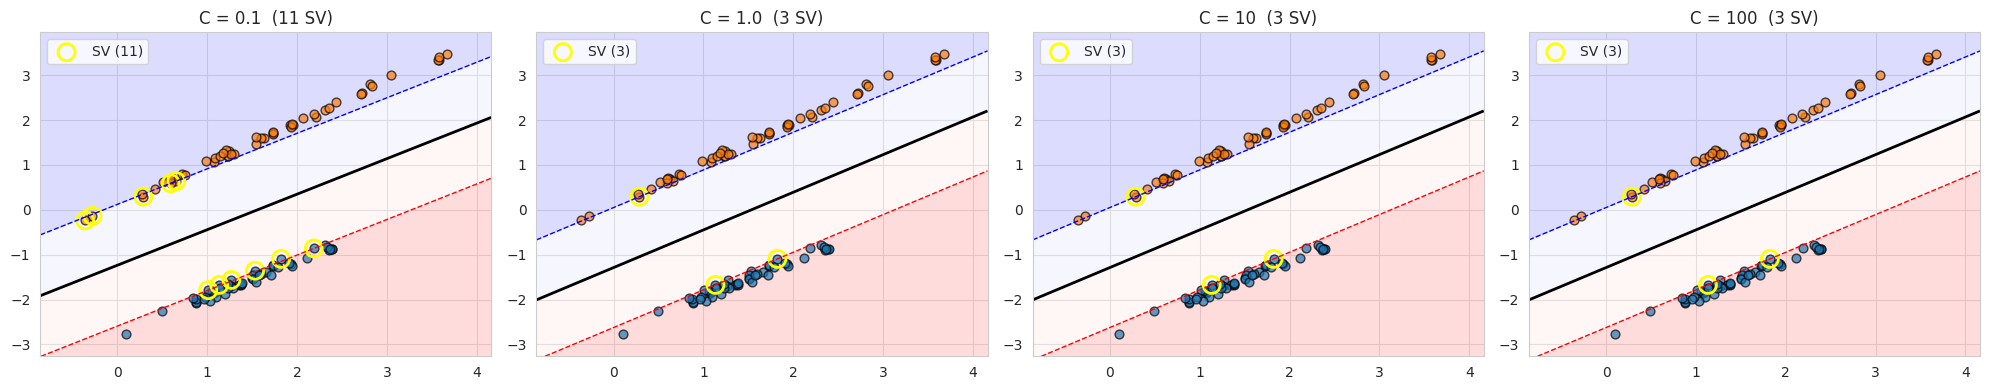

In [ ]:
from sklearn.svm import SVC

def plot_decision_boundary(X, y, clf, ax=None, title=""):
    """Visualiza la frontera de decisión y los vectores de soporte."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-1e6, -1, 0, 1, 1e6],
                colors=["#FFBBBB", "#FFEEEE", "#EEEEFF", "#BBBBFF"], alpha=0.5)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors=["red", "black", "blue"],
               linestyles=["--", "-", "--"], linewidths=[1, 2, 1])
    for k in [0, 1]:
        ax.scatter(X[y == k, 0], X[y == k, 1], alpha=0.7, edgecolor="k", s=40)
    # Vectores de soporte
    if hasattr(clf, "support_vectors_"):
        ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
                   s=150, facecolors="none", edgecolors="yellow", linewidths=2,
                   label=f"SV ({len(clf.support_vectors_)})")
        ax.legend()
    ax.set_title(title)

# Comparar SVM lineal con distintos C — ampliado
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, C in zip(axes, [0.1, 1.0, 10, 100]):
    clf = SVC(kernel="linear", C=C)
    clf.fit(X_lin, y_lin)
    n_sv = len(clf.support_vectors_)
    plot_decision_boundary(X_lin, y_lin, clf, ax=ax,
                           title=f"C = {C}  ({n_sv} SV)")
plt.tight_layout()
plt.show()

**Observá:** los círculos amarillos son los **vectores de soporte**. La línea negra es el hiperplano. Las líneas rojas/azules punteadas marcan el margen.

- $C = 0.1$: margen ancho, **muchos** vectores de soporte (modelo "blando").
- $C = 100$: margen angosto, **pocos** vectores de soporte (modelo más "rígido").

## ⚙️ Ejercicio 1 — SVM lineal vs logística regularizada (8 min)

**Tu tarea:**

Sobre el dataset breast cancer (cargalo igual que en Clase 4):

a) Ajustá un `SVC(kernel="linear")` con `C` elegido por CV 5-fold (usá `GridSearchCV`).
b) Compará accuracy y AUC en test con una `LogisticRegression(penalty="l2")` también tuneada por CV.
c) ¿Cuál gana? ¿Por mucho?

In [ ]:
# TU CÓDIGO ACÁ
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# a) SVM lineal con GridSearchCV
# b) Logística L2 con CV
# c) Comparar accuracy y AUC

---

# El truco del kernel

## ¿Y si los datos NO son linealmente separables?

Para el dataset de "lunas" no hay un hiperplano que separe. Necesitamos una frontera **no lineal**.

**Idea:** mapear los datos a un espacio de mayor dimensión donde sí sean linealmente separables, separar allí, y volver.

**El truco:** no hace falta calcular ese mapeo $\phi(x)$ explícitamente. SVM sólo usa **productos internos** $\langle x_i, x_j \rangle$. Si tenemos una función **kernel** $K(x_i, x_j) = \langle \phi(x_i), \phi(x_j) \rangle$, podemos trabajar como si estuviéramos en el espacio mapeado sin nunca visitarlo.

## Kernels estándar

| Kernel | Fórmula | Cuándo |
|---|---|---|
| Lineal | $K(x, x') = x^T x'$ | Datos linealmente separables, alta dim |
| Polinómico | $K(x, x') = (x^T x' + 1)^d$ | Interacciones de orden $d$ |
| RBF (gaussiano) | $K(x, x') = e^{-\gamma \|x - x'\|^2}$ | Default razonable, muy flexible |

## El parámetro γ del RBF

$\gamma$ controla cuán "local" es cada vector de soporte:

- $\gamma$ chico: kernels anchos, frontera suave (alto sesgo).
- $\gamma$ grande: kernels angostos, frontera flexible (alta varianza, sobreajuste).

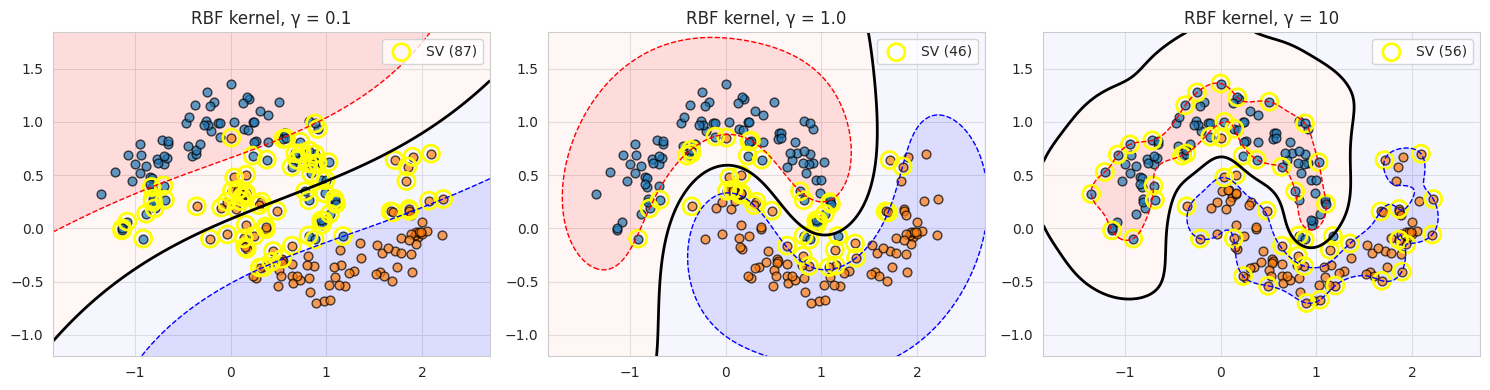

In [ ]:
# SVM con kernel RBF sobre el dataset de lunas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, gamma in zip(axes, [0.1, 1.0, 10]):
    clf = SVC(kernel="rbf", C=1, gamma=gamma)
    clf.fit(X_moons, y_moons)
    plot_decision_boundary(X_moons, y_moons, clf, ax=ax,
                           title=f"RBF kernel, γ = {gamma}")
plt.tight_layout()
plt.show()

**Observá:**

- $\gamma = 0.1$: frontera casi lineal (sub-ajuste).
- $\gamma = 1$: separa bien las dos lunas.
- $\gamma = 10$: frontera muy "rugosa", isla por cada punto (sobreajuste).

## ⚙️ Ejercicio 2 — Comparar kernels en lunas (10 min)

**Tu tarea:**

Aplicá `SVC` al dataset de lunas con cuatro kernels: lineal, polinómico (`degree=3`), RBF y sigmoid. Visualizá las fronteras de decisión lado a lado.

¿Cuál es el más adecuado para este problema? ¿Por qué?

In [ ]:
# TU CÓDIGO ACÁ
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
# Ajustar y graficar para cada kernel

---

# Tuning de C y γ

C y γ son dos hiperparámetros que interactúan. La práctica estándar es **búsqueda en grilla logarítmica con CV**.

## Cross-validation: recordatorio
Antes de tunear hiperparámetros, recordemos qué hace cross-validation (CV), que ya usamos en clases anteriores.

**El problema**: queremos elegir el mejor C (o γ, o α\alpha
α, etc.) sin mirar el test.
Si miramos el test para elegir hiperparámetros, ya no es un test honesto: lo estamos usando para entrenar (en un sentido amplio).

**La solución de CV (5-fold como ejemplo):**

1. Dividir el train en 5 partes iguales (folds).
2. Para cada combinación de hiperparámetros candidata:
 - Para cada uno de los 5 folds:
    - Entrenar el modelo con los otros 4 folds.
    - Evaluar en el fold que quedó afuera.
 - Promediar las 5 evaluaciones → score CV.
3. Quedarse con la combinación que tiene mejor score CV.
4. Re-entrenar ese modelo final con todo el train.
5. Evaluar una sola vez en test.

Cada combinación de hiperparámetros se "prueba" 5 veces sobre 5 splits distintos, y se promedia. Eso hace la estimación más estable que un único split train/val.

> Vamos a profundizar en CV (y sus problemas sutiles) en Clase 6, donde vamos a ver que incluso CV puede sobreestimar la performance si lo usamos mal. Por ahora, alcanza con la idea básica.

## Grilla logarítmica: por qué log y no lineal
Cuando buscamos el mejor C (o γ, o α), tenemos que probar una grilla de valores. La pregunta es: ¿qué valores probar?

Grilla lineal. Probar C ∈ {1, 2, 3, 4, 5, ...} parece intuitivo pero es ineficiente. **La razón: el efecto de C no es lineal**. Cambiar C de 1 a 2 tiene mucho más impacto que cambiar C de 100 a 101.

**Grilla logarítmica**. Probar C ∈ {0.01, 0.1, 1, 10, 100} cubre 4 órdenes de magnitud con 5 valores. Cada valor es 10 veces el anterior, no "uno más". Esto refleja la realidad de que los hiperparámetros se comportan en escala logarítmica.

En Python:
```
import numpy as np

# Grilla logarítmica de C, de 10^-2 a 10^2, con 5 valores
np.logspace(-2, 2, 5)
# array([0.01, 0.1, 1, 10, 100])

# Más fina: 9 valores entre 10^-2 y 10^2
np.logspace(-2, 2, 9)
# array([0.01, 0.0316, 0.1, 0.316, 1, 3.16, 10, 31.6, 100])
```
### Estrategia práctica de búsqueda:

1. Búsqueda gruesa primero: grilla logarítmica amplia con pocos valores (5-7) cubriendo varios órdenes de magnitud. Esto te ubica la región del óptimo.

2. Búsqueda fina después: grilla más densa alrededor del óptimo grueso, en una región más estrecha.

Esto es mucho más eficiente que probar 100 valores espaciados uniformemente en una grilla densa desde el principio.
### Por qué C y γ se buscan juntos
**Un detalle importante: C y γ interactúan**. No es válido fijar uno y optimizar el otro por separado, porque el óptimo de uno depende del valor del otro.

γ controla cuán "local" es el kernel RBF. C controla cuán fuerte es la regularización. Si γ es grande (kernel muy local), necesitás regularización más fuerte (C chico) para no sobreajustar. Si γ es chico (kernel suave), podés permitirte menos regularización (C grande).

Por eso ```GridSearchCV``` con un diccionario de dos parámetros prueba todas las combinaciones (producto cartesiano):
```
param_grid = {
    "C": np.logspace(-2, 2, 5),       # 5 valores
    "gamma": np.logspace(-3, 1, 5),   # 5 valores
}
# GridSearchCV va a probar 5 × 5 = 25 combinaciones,
# cada una con CV 5-fold = 125 ajustes en total.
```
El resultado es un heatmap de scores donde podés ver visualmente la región del óptimo


## Visualización de la grilla

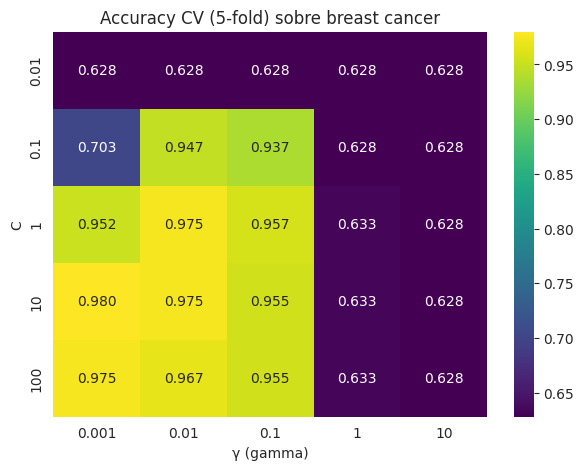

Mejor combinación: C = 10.0, γ = 0.001
Accuracy CV: 0.980
Accuracy en test: 0.971


In [ ]:
from sklearn.model_selection import GridSearchCV

# Búsqueda en grilla sobre breast cancer
param_grid = {
    "C": np.logspace(-2, 2, 5),
    "gamma": np.logspace(-3, 1, 5),
}
grid = GridSearchCV(SVC(kernel="rbf"), param_grid, cv=5, n_jobs=-1)
grid.fit(X_train_s, y_train)

# Heatmap de scores
scores = grid.cv_results_["mean_test_score"].reshape(5, 5)

plt.figure(figsize=(7, 5))
sns.heatmap(scores,
            xticklabels=[f"{g:.3g}" for g in param_grid["gamma"]],
            yticklabels=[f"{c:.3g}" for c in param_grid["C"]],
            annot=True, fmt=".3f", cmap="viridis")
plt.xlabel("γ (gamma)")
plt.ylabel("C")
plt.title("Accuracy CV (5-fold) sobre breast cancer")
plt.show()

print(f"Mejor combinación: C = {grid.best_params_['C']}, γ = {grid.best_params_['gamma']}")
print(f"Accuracy CV: {grid.best_score_:.3f}")
print(f"Accuracy en test: {grid.score(X_test_s, y_test):.3f}")

## ⚙️ Ejercicio 3 — Grilla fina y curva de aprendizaje (8 min)

**Tu tarea:**

a) Refiná la grilla alrededor del mejor punto del heatmap (rango más estrecho, más puntos).

b) **Visualización:** ¿qué pasa con el accuracy si la grilla se vuelve demasiado fina? ¿O demasiado gruesa?

c) Una vez elegido el mejor C y γ, hacé una **curva de aprendizaje**: cómo cambia el accuracy CV al aumentar el tamaño del train. Sklearn tiene `learning_curve`.

In [ ]:
from sklearn.model_selection import learning_curve

# TU CÓDIGO ACÁ
# a) Grilla más fina
# b) Heatmap
# c) Curva de aprendizaje

---

# Kernels para datos biológicos

## ¿Y si tus datos no son vectores?

En biología muchas veces tenés:

- **Secuencias** (DNA, RNA, proteínas): "ATGCCG..." de largo variable.
- **Grafos** (redes de interacción proteína-proteína).
- **Árboles filogenéticos**.

No podés meter directamente eso a SVM. Pero **podés definir un kernel** que capture similaridad entre estos objetos.

## String kernels

El kernel más sencillo es el **spectrum kernel**: $K(s, s')$ = número de k-mers comunes entre dos secuencias.

Vamos a implementarlo y probarlo en una tarea simplificada de clasificación de secuencias.

In [ ]:
# Generamos secuencias sintéticas: clase 0 enriquecida en "AT", clase 1 en "GC"
def generar_secuencia(longitud, sesgo_AT, rng):
    """sesgo_AT en [0, 1]: 1 = 100% AT, 0 = 100% GC."""
    probs = np.array([sesgo_AT/2, 1-sesgo_AT/2-sesgo_AT/2, sesgo_AT/2, 1-sesgo_AT/2-sesgo_AT/2])
    probs = np.clip(probs, 0, 1); probs = probs / probs.sum()
    # Mejor versión: simple bernoulli sobre AT vs GC, y dentro de cada par mezcla aleatoria
    seq = []
    for _ in range(longitud):
        if rng.random() < sesgo_AT:
            seq.append(rng.choice(["A", "T"]))
        else:
            seq.append(rng.choice(["G", "C"]))
    return "".join(seq)

rng = np.random.RandomState(0)
n_per_class = 50

seqs = []
labels = []
for _ in range(n_per_class):
    seqs.append(generar_secuencia(50, sesgo_AT=0.7, rng=rng))
    labels.append(0)
    seqs.append(generar_secuencia(50, sesgo_AT=0.3, rng=rng))
    labels.append(1)

labels = np.array(labels)
print(f"Generadas {len(seqs)} secuencias de longitud 50")
print(f"Ejemplo clase 0 (AT-rich): {seqs[0]}")
print(f"Ejemplo clase 1 (GC-rich): {seqs[1]}")

Generadas 100 secuencias de longitud 50
Ejemplo clase 0 (AT-rich): TCTAAAAGTGTTCCCTATCTTGATAAATTGAATAACTGTATATCGATGCT
Ejemplo clase 1 (GC-rich): ACAGCACGTACGGAGTTGCGGGAGCACGCGGCGCTCTGTTCACTGGCCGC


In [ ]:
def kmers(seq, k):
    """Devuelve un Counter con los k-mers de la secuencia."""
    from collections import Counter
    return Counter(seq[i:i+k] for i in range(len(seq) - k + 1))

def spectrum_kernel(seqs, k):
    """Devuelve la matriz de kernel KxK con productos internos de vectores de k-mers."""
    counters = [kmers(s, k) for s in seqs]
    # Vocabulario común
    vocab = set()
    for c in counters:
        vocab.update(c.keys())
    vocab = sorted(vocab)
    # Matriz n × |vocab|
    X = np.zeros((len(seqs), len(vocab)))
    for i, c in enumerate(counters):
        for j, kmer in enumerate(vocab):
            X[i, j] = c.get(kmer, 0)
    # Matriz kernel = X @ X.T
    return X @ X.T, X, vocab

# Kernel con k=3
K_train, X_kmers, vocab = spectrum_kernel(seqs, k=3)
print(f"Matriz de kernel: {K_train.shape}")
print(f"Vocabulario: {len(vocab)} k-mers únicos de longitud 3")

Matriz de kernel: (100, 100)
Vocabulario: 64 k-mers únicos de longitud 3


In [ ]:
# Entrenamos SVM con kernel precomputado
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# Split
indices = np.arange(len(seqs))
idx_train, idx_test = train_test_split(indices, test_size=0.3, random_state=0, stratify=labels)

# Kernel precomputado: K[train, train] y K[test, train]
K_tr = K_train[np.ix_(idx_train, idx_train)]
K_te = K_train[np.ix_(idx_test, idx_train)]

clf = SVC(kernel="precomputed", C=1.0)
clf.fit(K_tr, labels[idx_train])
acc = clf.score(K_te, labels[idx_test])
print(f"Accuracy de SVM con spectrum kernel (k=3): {acc:.3f}")

Accuracy de SVM con spectrum kernel (k=3): 0.967


## ⚙️ Ejercicio 4 — Spectrum kernel con distintos k (10 min)

**Tu tarea:**

a) Aplicá el spectrum kernel con $k \in \{1, 2, 3, 4, 5\}$. ¿Cuál da mejor accuracy?

b) **Pregunta conceptual:** ¿qué pasa cuando $k$ es muy grande respecto al largo de la secuencia? ¿Y cuando $k=1$?

c) ¿Cómo extenderías esto para detectar **motivos** (k-mers específicos como "TATA")?

In [ ]:
# TU CÓDIGO ACÁ
# Para cada k, calcular K y reportar accuracy

---

# Cierre — Ejercicio integrador

## ⚙️ Ejercicio 5 — Decisión rápida (5 min, escrito)

Para cada situación, indicá qué SVM (qué kernel, qué hiperparámetros aproximados) usarías:

**A:** Clasificación de imágenes histopatológicas (vectores de 1024 features extraídos por una red).

**B:** Clasificación de proteínas en familias funcionales desde su secuencia de aminoácidos.

**C:** Predicción de respuesta a tratamiento desde 50 biomarcadores tabulares con n=300 pacientes.

**D:** Detección de outliers en datos de RNA-seq (todos los pacientes son del mismo tipo, querés encontrar los raros).

**Tus respuestas:**

- **A:** ___
- **B:** ___
- **C:** ___
- **D:** ___

---

## Resumen

| Concepto | Idea clave |
|---|---|
| **Margen máximo** | Hiperplano más alejado de los puntos de cada clase |
| **Vectores de soporte** | Los pocos puntos que definen la frontera |
| **C (soft margin)** | Trade-off margen ancho ↔ violaciones |
| **Kernel trick** | Trabajar en espacios complejos sin computarlos |
| **γ del RBF** | Local ↔ global; chico = suave, grande = rugoso |
| **String kernels** | Llevan SVM a secuencias y otros datos no vectoriales |

**Reglas prácticas:**

1. **Escalar siempre** las variables (más crítico que en regresión).
2. **Empezar con RBF**: kernel default razonable.
3. **Tunear C y γ con grid search en escala log**.
4. **Comparar con logística L2**: si la lineal funciona casi igual, no compliques.

## Conexión con la próxima clase

Hoy ajustamos SVM con GridSearchCV. En la **Clase 6** vamos a ver por qué esto **sobreestima** el rendimiento en datos de alta dimensión y cómo arreglarlo con **nested CV**. También cómo **interpretar** modelos no lineales (SHAP) e introducción a **deep learning**.

---

*Bibliografía y videos en `bibliografia_clase5.md`. Soluciones en `Clase5_Soluciones.ipynb`.*